In [1]:
import datasets
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

/home/jmendoza/miniconda3/envs/proyecto/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load MessIRve test split
messirve = datasets.load_dataset("spanish-ir/messirve", "full", revision="1.2")
test = messirve["test"]

# Count relevant documents per query
rels_per_query = Counter(test["id"])
counts = np.array(list(rels_per_query.values()))

# Summary statistics
print(f"Queries:  {len(counts):,}")
print(f"Min:      {counts.min()}")
print(f"Max:      {counts.max()}")
print(f"Mean:     {counts.mean():.2f}")
print(f"Median:   {np.median(counts):.1f}")
print(f"Std:      {counts.std():.2f}")

Queries:  170,055
Min:      1
Max:      4
Mean:     1.02
Median:   1.0
Std:      0.16


Queries:  170,055
  1 rel doc(s): 166,201 queries (97.7337%)
  2 rel doc(s):   3,698 queries (2.1746%)
  3 rel doc(s):     143 queries (0.0841%)
  4 rel doc(s):      13 queries (0.0076%)


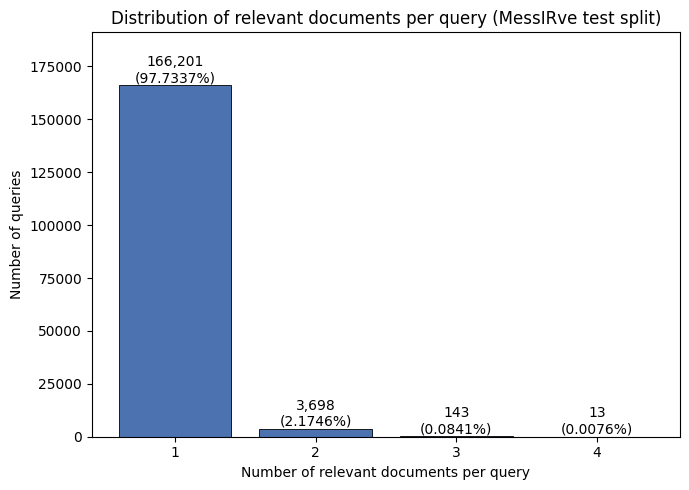

In [3]:
# Frequency of each count (1, 2, 3, 4)
freq = Counter(counts)
labels = sorted(freq.keys())
values = [freq[k] for k in labels]

# Summary statistics
print(f"Queries:  {len(counts):,}")
for k, v in sorted(freq.items()):
    print(f"  {k} rel doc(s): {v:>7,} queries ({v / len(counts) * 100:.4f}%)")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color="#4C72B0", edgecolor="black", linewidth=0.6)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{v:,}\n({v / len(counts) * 100:.4f}%)",
            ha="center", va="bottom", fontsize=10)

ax.set_xticks(labels)
ax.set_xlabel("Number of relevant documents per query")
ax.set_ylabel("Number of queries")
ax.set_title("Distribution of relevant documents per query (MessIRve test split)")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

Map (num_proc=32): 100%|██████████| 14047759/14047759 [00:08<00:00, 1665407.03 examples/s]



Queries (170,055 items)
  Min:    3
  Max:    22
  Mean:   5.70
  Median: 5.0
  Std:    1.88
  P75:    7
  P90:    8
  P95:    9
  P99:    12

Documents (14,047,759 items)
  Min:    5
  Max:    9,757
  Mean:   59.41
  Median: 47.0
  Std:    49.51
  P75:    79
  P90:    121
  P95:    153
  P99:    233


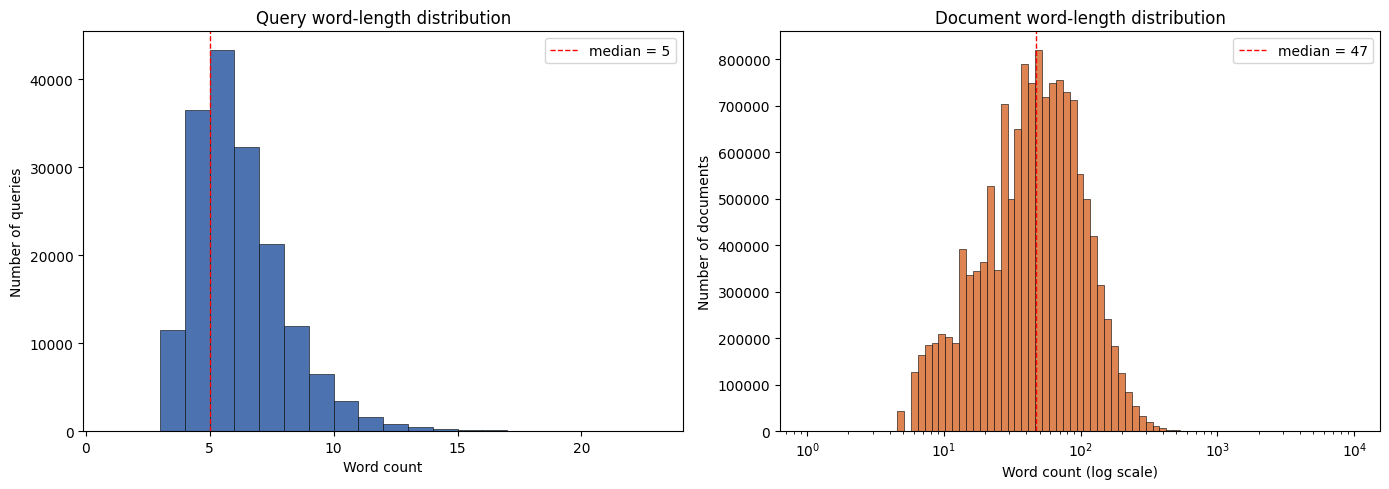

In [4]:
# --- Word-length distributions: queries & documents ---

# Unique queries
unique_queries = dict(zip(test["id"], test["query"]))
query_wc = np.array([len(q.split()) for q in unique_queries.values()])

# Document word counts (title + text, same formatting as the pipeline)
corpus = datasets.load_dataset("spanish-ir/eswiki_20240401_corpus", split="corpus")
def _word_count(batch):
    counts = []
    for title, text in zip(batch["title"], batch["text"]):
        title = title or ""
        text = text or ""
        full = f"{title}. {text}".strip() if title else text
        counts.append(len(full.split()))
    return {"word_count": counts}

corpus = corpus.map(_word_count, batched=True, batch_size=10_000, num_proc=32)
doc_wc = np.array(corpus["word_count"])

# Summary statistics
for name, wc in [("Queries", query_wc), ("Documents", doc_wc)]:
    print(f"\n{name} ({len(wc):,} items)")
    print(f"  Min:    {wc.min()}")
    print(f"  Max:    {wc.max():,}")
    print(f"  Mean:   {wc.mean():.2f}")
    print(f"  Median: {np.median(wc):.1f}")
    print(f"  Std:    {wc.std():.2f}")
    for p in [75, 90, 95, 99]:
        print(f"  P{p}:    {np.percentile(wc, p):.0f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(query_wc, bins=range(1, query_wc.max() + 2), color="#4C72B0",
        edgecolor="black", linewidth=0.4)
ax1.set_xlabel("Word count")
ax1.set_ylabel("Number of queries")
ax1.set_title("Query word-length distribution")
ax1.axvline(np.median(query_wc), color="red", ls="--", lw=1, label=f"median = {np.median(query_wc):.0f}")
ax1.legend()

ax2.hist(doc_wc, bins=np.logspace(0, np.log10(doc_wc.max() + 1), 80),
        color="#DD8452", edgecolor="black", linewidth=0.4)
ax2.set_xscale("log")
ax2.set_xlabel("Word count (log scale)")
ax2.set_ylabel("Number of documents")
ax2.set_title("Document word-length distribution")
ax2.axvline(np.median(doc_wc), color="red", ls="--", lw=1, label=f"median = {np.median(doc_wc):.0f}")
ax2.legend()

plt.tight_layout()
plt.show()